In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('audit_sample.csv')

# Inspect the first few rows
print("Head of the data:")
print(df.head())

# Get info about the columns
print("\nData Info:")
print(df.info())

# Count the occurrences of different Event IDs
if 'Event ID' in df.columns:
    print("\nEvent ID Counts:")
    print(df['Event ID'].value_counts())
else:
    print("\n'Event ID' column not found.")

# Inspect the 'Message' column (if it exists, though looking at the snippet, the info might be in a different format)
# The snippet shows headers: Keywords, Date and Time, Source, Event ID, Task Category
# But it also shows a large text block. Let's see how pandas parsed it.

Head of the data:
                            Keywords                        Date and Time  \
Audit Failure  5/11/2026 10:29:28 AM  Microsoft-Windows-Security-Auditing   
Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   
Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   

               Source       Event ID  \
Audit Failure    4625          Logon   
Audit Success    4672  Special Logon   
Audit Success    4624          Logon   
Audit Success    4672  Special Logon   
Audit Success    4624          Logon   

                                                   Task Category  
Audit Failure  An account failed to log on.\r\n\r\nSubject:\r...  
Audit Success  Special privileges assigned to new logon.\r\n\...  
Audit Success  An account was successfully logged on.\r\n\r\n...  
Audit Succ

In [2]:
with open('audit_sample.csv', 'r') as f:
    for _ in range(5):
        print(f.readline())

Keywords,Date and Time,Source,Event ID,Task Category

Audit Failure,5/11/2026 10:29:28 AM,Microsoft-Windows-Security-Auditing,4625,Logon,"An account failed to log on.



Subject:

	Security ID:		NULL SID



In [3]:
# Try reading without index and skipping the empty line
df = pd.read_csv('audit_sample.csv', index_col=False, skip_blank_lines=True)
print(df.head())
print(df.columns)
print(df['Event ID'].value_counts())

        Keywords          Date and Time                               Source  \
0  Audit Failure  5/11/2026 10:29:28 AM  Microsoft-Windows-Security-Auditing   
1  Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
2  Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
3  Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   
4  Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   

   Event ID  Task Category  
0      4625          Logon  
1      4672  Special Logon  
2      4624          Logon  
3      4672  Special Logon  
4      4624          Logon  
Index(['Keywords', 'Date and Time', 'Source', 'Event ID', 'Task Category'], dtype='object')
Event ID
4625    18141
4624      367
4672      363
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_3976\1854603134.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv('audit_sample.csv', index_col=False, skip_blank_lines=True)


In [4]:
# Look at a sample Task Category for a 4625 event
sample_4625 = df[df['Event ID'] == 4625]['Task Category'].iloc[0]
print("Sample 4625 text:")
print(sample_4625[:1000]) # Print first 1000 chars

# Look at a sample Task Category for a 4624 event
sample_4624 = df[df['Event ID'] == 4624]['Task Category'].iloc[0]
print("\nSample 4624 text:")
print(sample_4624[:1000])

Sample 4625 text:
Logon

Sample 4624 text:
Logon


In [5]:
# Read without headers to see how many columns there are
df_raw = pd.read_csv('audit_sample.csv', header=None, skiprows=2)
print(df_raw.head())
print("Number of columns:", df_raw.shape[1])

               0                      1                                    2  \
0  Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
1  Audit Success  5/11/2026 10:24:38 AM  Microsoft-Windows-Security-Auditing   
2  Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   
3  Audit Success  5/11/2026 10:24:24 AM  Microsoft-Windows-Security-Auditing   
4  Audit Failure  5/11/2026 10:22:56 AM  Microsoft-Windows-Security-Auditing   

      3              4                                                  5  
0  4672  Special Logon  Special privileges assigned to new logon.\r\n\...  
1  4624          Logon  An account was successfully logged on.\r\n\r\n...  
2  4672  Special Logon  Special privileges assigned to new logon.\r\n\...  
3  4624          Logon  An account was successfully logged on.\r\n\r\n...  
4  4625          Logon  An account failed to log on.\r\n\r\nSubject:\r...  
Number of columns: 6


In [6]:
import pandas as pd
import re

# Read the file with 6 columns
cols = ['Keywords', 'Timestamp', 'Source', 'EventID', 'Task', 'Message']
df = pd.read_csv('audit_sample.csv', names=cols, skiprows=2, skip_blank_lines=True)

# Function to extract username from the message
def extract_username(msg):
    # For 4625, it's under 'Account For Which Logon Failed'
    match = re.search(r'Account Name:\s+(.*?)\s', msg, re.DOTALL)
    if match:
        # If there are multiple 'Account Name' entries, let's try to find the one after 'Account For Which Logon Failed'
        parts = re.split(r'Account For Which Logon Failed:', msg)
        if len(parts) > 1:
            match_sub = re.search(r'Account Name:\s+(.*?)\s', parts[1])
            if match_sub:
                return match_sub.group(1).strip()
    return "Unknown"

# Function to extract IP address from the message
def extract_ip(msg):
    match = re.search(r'Source Network Address:\s+(.*?)\s', msg)
    if match:
        ip = match.group(1).strip()
        if ip == '-': return "Local/System"
        return ip
    return "Unknown"

# Apply extractions
df['Username'] = df['Message'].apply(extract_username)
df['IP_Address'] = df['Message'].apply(extract_ip)

# Filter for Failed Logons (4625)
failed_logons = df[df['EventID'] == 4625]

print("Top 10 IP Addresses for Failed Logons:")
print(failed_logons['IP_Address'].value_counts().head(10))

print("\nTop 10 Target Usernames for Failed Logons:")
print(failed_logons['Username'].value_counts().head(10))

# Save the cleaned data to a new CSV for the user's project
cleaned_file = 'cleaned_audit_data.csv'
df[['Timestamp', 'EventID', 'Username', 'IP_Address', 'Keywords']].to_csv(cleaned_file, index=False)
print(f"\nCleaned data saved to {cleaned_file}")

Top 10 IP Addresses for Failed Logons:
IP_Address
148.251.140.16     15454
82.67.135.231       1046
211.44.183.197       822
83.165.106.28        288
45.227.254.44        249
45.238.132.70        115
103.212.182.194       51
54.151.176.0          30
45.142.193.145        30
112.172.40.199        16
Name: count, dtype: int64

Top 10 Target Usernames for Failed Logons:
Username
ADMIN            2859
USER             2857
TEST             2371
SERVER           2368
SUPPORT          2367
REMOTE           2363
ADMINISTRATOR    1308
PC                357
A                 205
ADMIN2            150
Name: count, dtype: int64

Cleaned data saved to cleaned_audit_data.csv


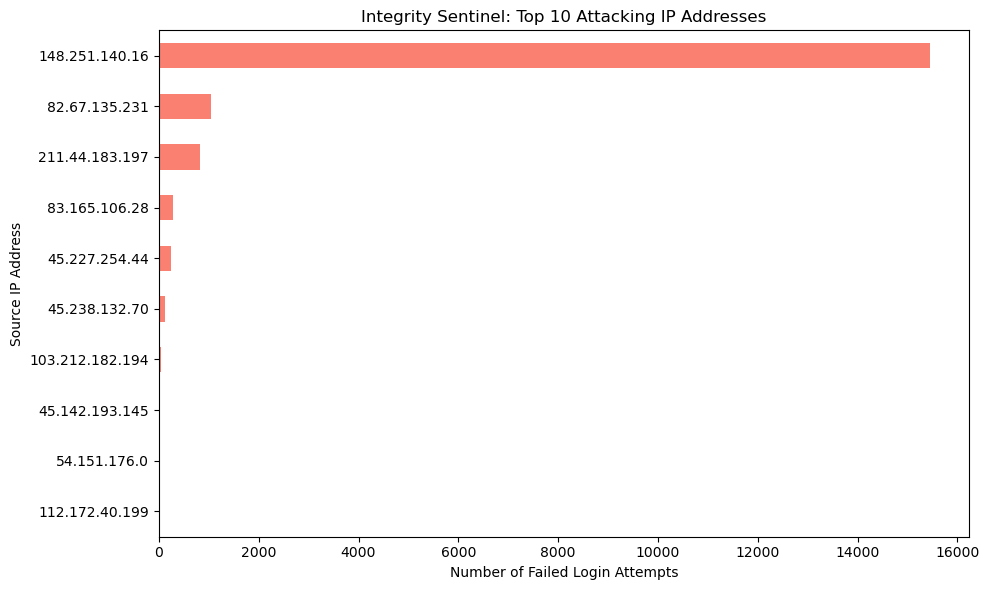

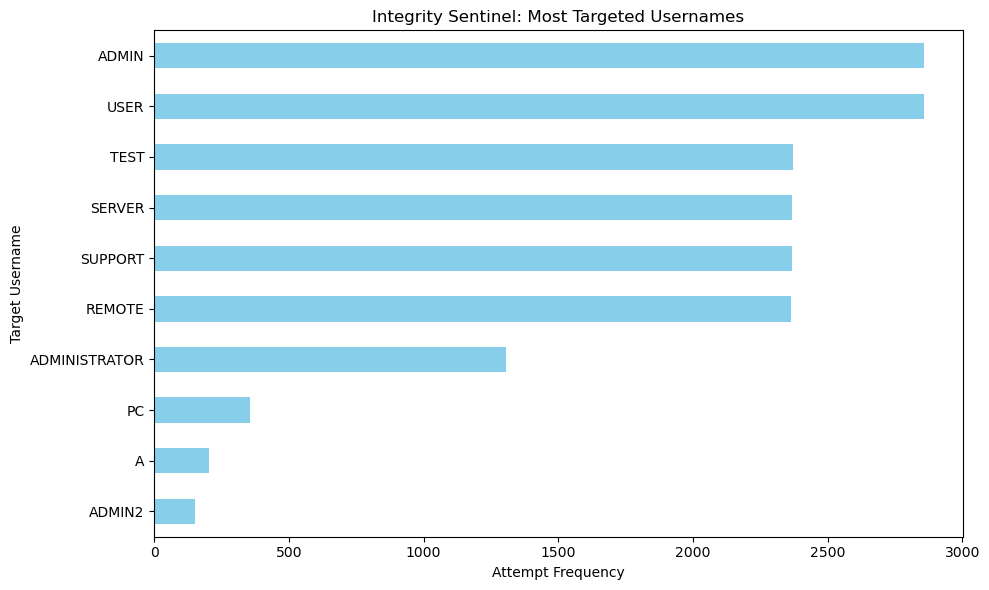

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the cleaned data from previous step
# I need to re-load the original data and clean it as the previous state might be lost or I want to be sure.
cols = ['Keywords', 'Timestamp', 'Source', 'EventID', 'Task', 'Message']
df = pd.read_csv('audit_sample.csv', names=cols, skiprows=2, skip_blank_lines=True)

import re
def extract_username(msg):
    parts = re.split(r'Account For Which Logon Failed:', str(msg))
    if len(parts) > 1:
        match_sub = re.search(r'Account Name:\s+(.*?)\s', parts[1])
        if match_sub:
            return match_sub.group(1).strip()
    return "Unknown"

def extract_ip(msg):
    match = re.search(r'Source Network Address:\s+(.*?)\s', str(msg))
    if match:
        ip = match.group(1).strip()
        if ip == '-': return "Local/System"
        return ip
    return "Unknown"

df['Username'] = df['Message'].apply(extract_username)
df['IP_Address'] = df['Message'].apply(extract_ip)
failed_logons = df[df['EventID'] == 4625]

# Plotting Top 10 Attacking IPs
plt.figure(figsize=(10, 6))
failed_logons['IP_Address'].value_counts().head(10).sort_values().plot(kind='barh', color='salmon')
plt.title('Integrity Sentinel: Top 10 Attacking IP Addresses')
plt.xlabel('Number of Failed Login Attempts')
plt.ylabel('Source IP Address')
plt.tight_layout()
plt.savefig('top_attacking_ips.png')

# Plotting Top 10 Targeted Usernames
plt.figure(figsize=(10, 6))
failed_logons['Username'].value_counts().head(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Integrity Sentinel: Most Targeted Usernames')
plt.xlabel('Attempt Frequency')
plt.ylabel('Target Username')
plt.tight_layout()
plt.savefig('targeted_usernames.png')